In [1]:
# ============================================
# NOTEBOOK 3: CORRELATION & DIVERSIFICATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("📊 PYTHON FINANCIAL ANALYSIS PROJECT")
print("="*60)
print("Notebook 3: Correlation & Diversification Analysis")
print("Author: Jonathan Nadeau")
print(f"Date: {datetime.now().strftime('%B %d, %Y')}")
print("="*60)
print("\n✅ All libraries imported successfully!")
print("\nThis notebook analyzes:")
print("  • Asset correlation matrices")
print("  • Rolling correlations over time")
print("  • Portfolio diversification benefits")
print("  • Optimal asset combinations")
print("\n" + "="*60)

📊 PYTHON FINANCIAL ANALYSIS PROJECT
Notebook 3: Correlation & Diversification Analysis
Author: Jonathan Nadeau
Date: February 12, 2026

✅ All libraries imported successfully!

This notebook analyzes:
  • Asset correlation matrices
  • Rolling correlations over time
  • Portfolio diversification benefits
  • Optimal asset combinations



In [2]:
# ============================================
# SECTION 1: LOAD DATA & CORRELATION MATRIX
# ============================================

# Load our returns data from Notebook 2
daily_returns = pd.read_csv('daily_returns_2015_2024.csv', index_col=0, parse_dates=True)

print("📊 DATA LOADED")
print("="*60)
print(f"✅ Daily returns loaded: {daily_returns.shape[0]} days × {daily_returns.shape[1]} assets")
print(f"Assets: {list(daily_returns.columns)}")

# Calculate correlation matrix
correlation_matrix = daily_returns.corr()

print("\n🔗 CORRELATION MATRIX")
print("="*60)
print(correlation_matrix.round(3))

print("\n📖 INTERPRETATION GUIDE:")
print("  • 1.0 = Perfect positive correlation (move together)")
print("  • 0.0 = No correlation (independent)")
print("  • -1.0 = Perfect negative correlation (move opposite)")
print("  • 0.7 to 1.0 = Strong positive correlation")
print("  • 0.3 to 0.7 = Moderate positive correlation")
print("  • -0.3 to 0.3 = Weak/no correlation")
print("  • -0.7 to -0.3 = Moderate negative correlation")
print("  • -1.0 to -0.7 = Strong negative correlation")

# Find strongest and weakest correlations
# Create a mask to ignore diagonal (self-correlation)
corr_values = correlation_matrix.values.copy()
np.fill_diagonal(corr_values, np.nan)

# Find max correlation
max_corr = np.nanmax(corr_values)
max_idx = np.where(correlation_matrix.values == max_corr)
max_pair = (correlation_matrix.index[max_idx[0][0]], correlation_matrix.columns[max_idx[1][0]])

# Find min correlation  
min_corr = np.nanmin(corr_values)
min_idx = np.where(correlation_matrix.values == min_corr)
min_pair = (correlation_matrix.index[min_idx[0][0]], correlation_matrix.columns[min_idx[1][0]])

print("\n🔍 KEY RELATIONSHIPS:")
print(f"  • Strongest correlation: {max_pair[0]} & {max_pair[1]} ({max_corr:.3f})")
print(f"  • Weakest correlation: {min_pair[0]} & {min_pair[1]} ({min_corr:.3f})")

if min_corr < 0:
    print(f"\n💡 DIVERSIFICATION OPPORTUNITY!")
    print(f"  • {min_pair[0]} and {min_pair[1]} have NEGATIVE correlation")
    print(f"  • When one goes up, the other tends to go down")
    print(f"  • This is ideal for portfolio diversification!")

print("\n" + "="*60)

📊 DATA LOADED
✅ Daily returns loaded: 2514 days × 6 assets
Assets: ['AAPL', 'EFA', 'GLD', 'SPY', 'TLT', 'XLE']

🔗 CORRELATION MATRIX
       AAPL    EFA    GLD    SPY    TLT    XLE
AAPL  1.000  0.583  0.029  0.747 -0.132  0.347
EFA   0.583  1.000  0.125  0.855 -0.183  0.622
GLD   0.029  0.125  1.000  0.047  0.312  0.057
SPY   0.747  0.855  0.047  1.000 -0.210  0.625
TLT  -0.132 -0.183  0.312 -0.210  1.000 -0.262
XLE   0.347  0.622  0.057  0.625 -0.262  1.000

📖 INTERPRETATION GUIDE:
  • 1.0 = Perfect positive correlation (move together)
  • 0.0 = No correlation (independent)
  • -1.0 = Perfect negative correlation (move opposite)
  • 0.7 to 1.0 = Strong positive correlation
  • 0.3 to 0.7 = Moderate positive correlation
  • -0.3 to 0.3 = Weak/no correlation
  • -0.7 to -0.3 = Moderate negative correlation
  • -1.0 to -0.7 = Strong negative correlation

🔍 KEY RELATIONSHIPS:
  • Strongest correlation: EFA & SPY (0.855)
  • Weakest correlation: TLT & XLE (-0.262)

💡 DIVERSIFICATION OPPORTU

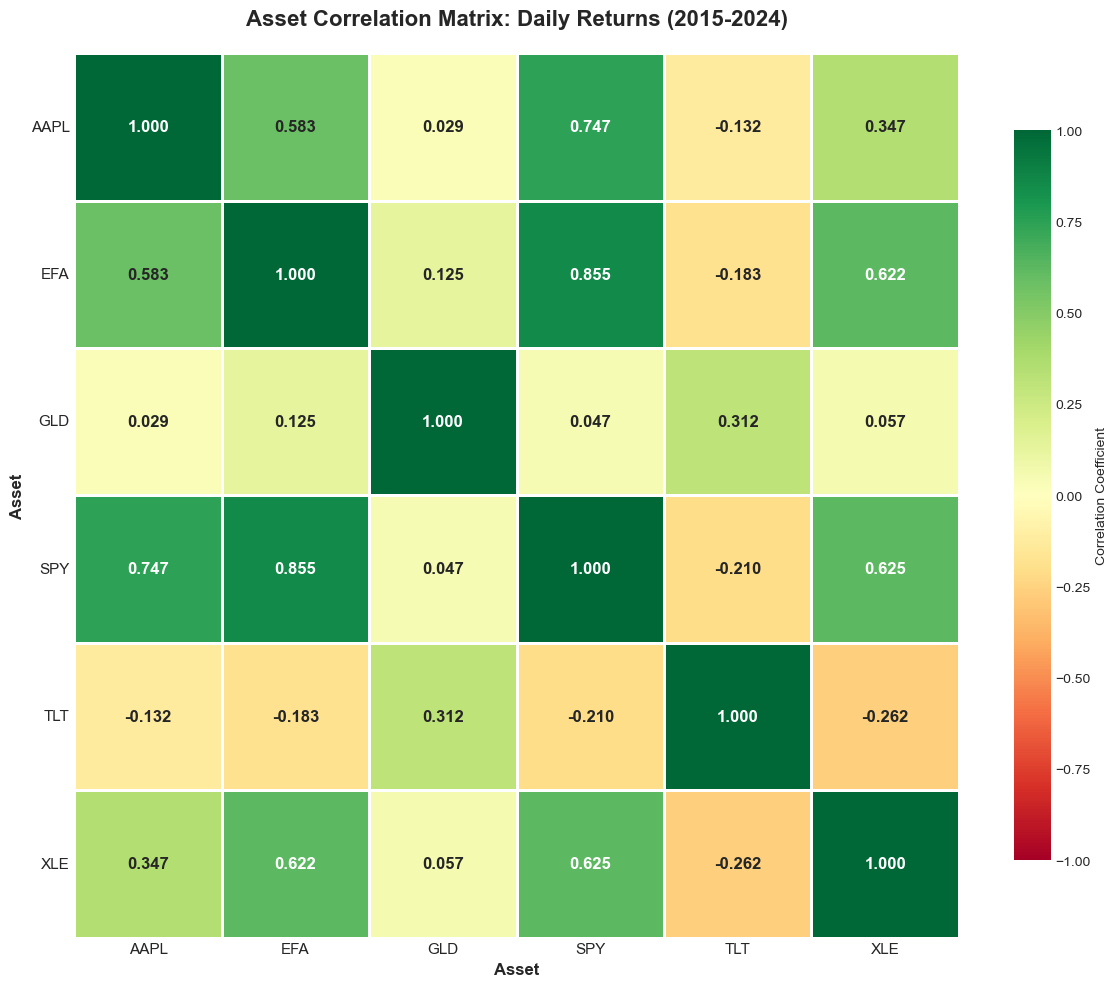

✅ Enhanced correlation heatmap saved as 'python_correlation_heatmap_detailed.png'

🎨 COLOR GUIDE:
  • Dark GREEN = Strong positive correlation (move together)
  • YELLOW = Weak/no correlation (independent)
  • RED = Negative correlation (move opposite)

💡 PORTFOLIO STRATEGY:
  • Combine GREEN assets with RED assets for diversification
  • Avoid portfolios with only GREEN assets (all move together = risky!)
  • TLT (bonds) shows red with many stocks = good diversifier


In [3]:
# ============================================
# SECTION 2: ENHANCED CORRELATION HEATMAP
# ============================================

# Create a large, detailed correlation heatmap
plt.figure(figsize=(12, 10))

# Create heatmap with annotations
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',  # Red-Yellow-Green colormap (red=negative, green=positive)
    center=0,
    square=True,
    linewidths=2,
    linecolor='white',
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    vmin=-1,
    vmax=1,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('Asset Correlation Matrix: Daily Returns (2015-2024)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Asset', fontsize=12, fontweight='bold')
plt.ylabel('Asset', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig('python_correlation_heatmap_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Enhanced correlation heatmap saved as 'python_correlation_heatmap_detailed.png'")
print("\n🎨 COLOR GUIDE:")
print("  • Dark GREEN = Strong positive correlation (move together)")
print("  • YELLOW = Weak/no correlation (independent)")
print("  • RED = Negative correlation (move opposite)")
print("\n💡 PORTFOLIO STRATEGY:")
print("  • Combine GREEN assets with RED assets for diversification")
print("  • Avoid portfolios with only GREEN assets (all move together = risky!)")
print("  • TLT (bonds) shows red with many stocks = good diversifier")

📈 CALCULATING ROLLING CORRELATIONS
Shows how asset relationships change during different market conditions



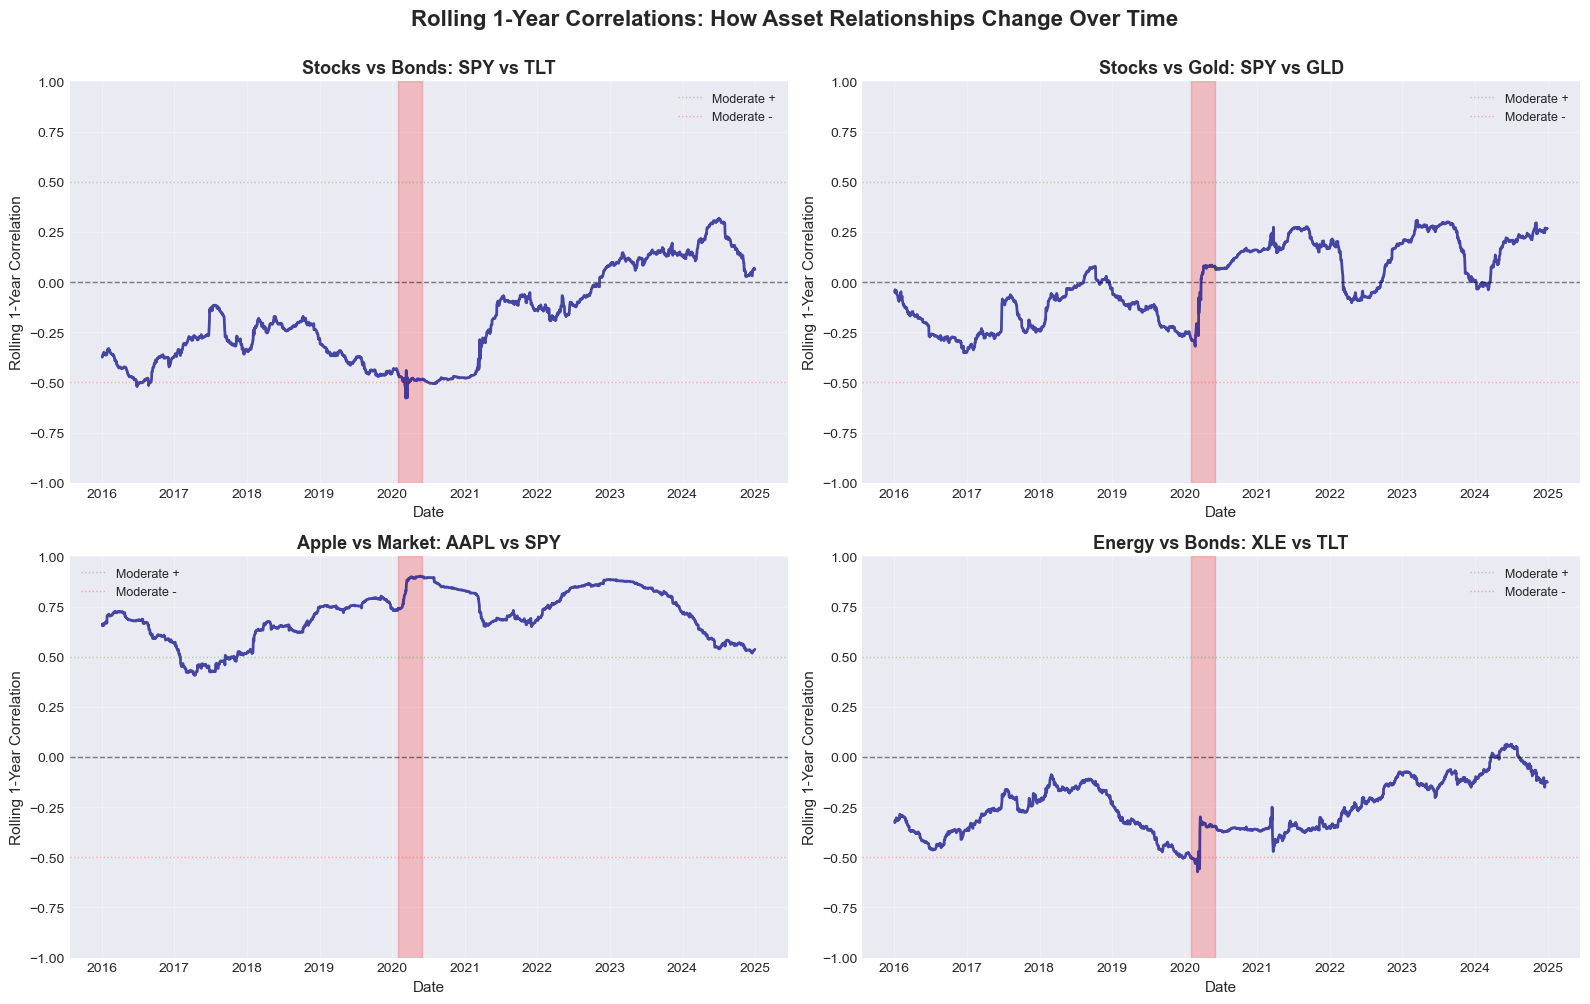

✅ Rolling correlation chart saved as 'python_rolling_correlations.png'

💡 KEY INSIGHTS:
  • Correlations are NOT static - they change over time!
  • During crises (red shaded), correlations often spike
  • Diversification works better in normal times
  • Stock-bond correlation often goes negative during stress


In [4]:
# ============================================
# SECTION 3: ROLLING CORRELATION OVER TIME
# ============================================

print("📈 CALCULATING ROLLING CORRELATIONS")
print("="*60)
print("Shows how asset relationships change during different market conditions\n")

# Calculate rolling 252-day (1-year) correlation for key pairs
window = 252

# Key pairs to track
pairs = [
    ('SPY', 'TLT', 'Stocks vs Bonds'),
    ('SPY', 'GLD', 'Stocks vs Gold'),
    ('AAPL', 'SPY', 'Apple vs Market'),
    ('XLE', 'TLT', 'Energy vs Bonds')
]

# Create subplots for each pair
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (asset1, asset2, label) in enumerate(pairs):
    # Calculate rolling correlation
    rolling_corr = daily_returns[asset1].rolling(window=window).corr(daily_returns[asset2])
    
    # Plot
    axes[idx].plot(rolling_corr.index, rolling_corr, linewidth=2, color='navy', alpha=0.7)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].axhline(y=0.5, color='green', linestyle=':', linewidth=1, alpha=0.3, label='Moderate +')
    axes[idx].axhline(y=-0.5, color='red', linestyle=':', linewidth=1, alpha=0.3, label='Moderate -')
    
    axes[idx].set_title(f'{label}: {asset1} vs {asset2}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Date', fontsize=11)
    axes[idx].set_ylabel('Rolling 1-Year Correlation', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].set_ylim(-1, 1)
    
    # Highlight COVID period
    axes[idx].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), 
                       alpha=0.2, color='red', label='COVID-19')

plt.suptitle('Rolling 1-Year Correlations: How Asset Relationships Change Over Time', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

# Save the figure
plt.savefig('python_rolling_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Rolling correlation chart saved as 'python_rolling_correlations.png'")
print("\n💡 KEY INSIGHTS:")
print("  • Correlations are NOT static - they change over time!")
print("  • During crises (red shaded), correlations often spike")
print("  • Diversification works better in normal times")
print("  • Stock-bond correlation often goes negative during stress")

💼 DEMONSTRATING DIVERSIFICATION BENEFITS
Comparing: All-Stock Portfolio vs Diversified Portfolio

📊 PORTFOLIO COMPARISON:
             Portfolio  Annual Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
     100% Stocks (SPY)          13.078173       17.622187      0.628649        -33.717263
Diversified (60/30/10)           8.925159       10.951305      0.632359        -24.895603


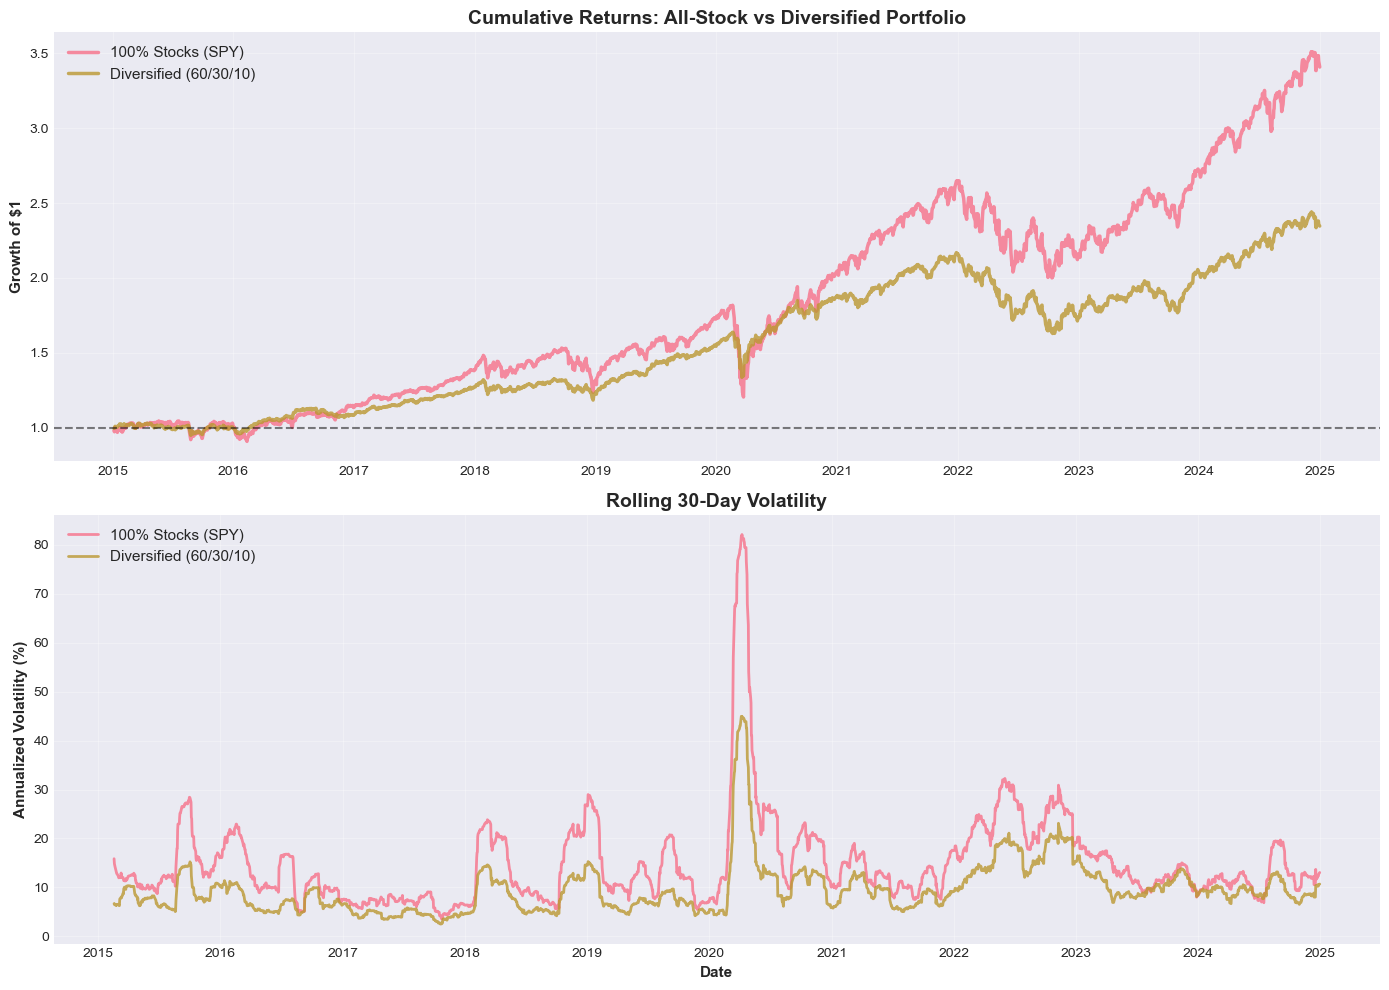


✅ Diversification comparison saved as 'python_diversification_benefit.png'

💡 DIVERSIFICATION BENEFITS:
  • Volatility reduced by: 6.67%
  • Sharpe ratio improved by: 0.004
  • Lower maximum drawdown in diversified portfolio

🎯 CONCLUSION:
  • Diversification reduces risk (volatility) while maintaining decent returns
  • Better risk-adjusted returns (higher Sharpe ratio)
  • Smoother ride with less severe drawdowns
  • The 'free lunch' of portfolio theory!


In [5]:
# ============================================
# SECTION 4: PORTFOLIO DIVERSIFICATION BENEFIT
# ============================================

print("💼 DEMONSTRATING DIVERSIFICATION BENEFITS")
print("="*60)
print("Comparing: All-Stock Portfolio vs Diversified Portfolio\n")

# Portfolio 1: All stocks (100% SPY)
portfolio_stocks = daily_returns['SPY']

# Portfolio 2: Diversified (60% stocks, 30% bonds, 10% gold)
portfolio_diversified = (
    0.60 * daily_returns['SPY'] +
    0.30 * daily_returns['TLT'] +
    0.10 * daily_returns['GLD']
)

# Calculate statistics for both portfolios
portfolios = {
    '100% Stocks (SPY)': portfolio_stocks,
    'Diversified (60/30/10)': portfolio_diversified
}

results = []
for name, portfolio in portfolios.items():
    # Annualized return
    cumulative = (1 + portfolio).prod()
    years = len(portfolio) / 252
    annual_return = (cumulative ** (1/years) - 1) * 100
    
    # Annualized volatility
    annual_vol = portfolio.std() * np.sqrt(252) * 100
    
    # Sharpe ratio
    sharpe = (annual_return - 2.0) / annual_vol
    
    # Max drawdown
    cum_returns = (1 + portfolio).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max * 100
    max_dd = drawdown.min()
    
    results.append({
        'Portfolio': name,
        'Annual Return (%)': annual_return,
        'Volatility (%)': annual_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    })

results_df = pd.DataFrame(results)
print("📊 PORTFOLIO COMPARISON:")
print(results_df.to_string(index=False))

# Visualize cumulative performance
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Cumulative returns
for name, portfolio in portfolios.items():
    cum_returns = (1 + portfolio).cumprod()
    axes[0].plot(cum_returns.index, cum_returns, linewidth=2.5, label=name, alpha=0.8)

axes[0].set_title('Cumulative Returns: All-Stock vs Diversified Portfolio', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Growth of $1', fontsize=11, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='black', linestyle='--', alpha=0.5)

# Bottom: Volatility (rolling 30-day std)
for name, portfolio in portfolios.items():
    rolling_vol = portfolio.rolling(30).std() * np.sqrt(252) * 100
    axes[1].plot(rolling_vol.index, rolling_vol, linewidth=2, label=name, alpha=0.8)

axes[1].set_title('Rolling 30-Day Volatility', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Annualized Volatility (%)', fontsize=11, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('python_diversification_benefit.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Diversification comparison saved as 'python_diversification_benefit.png'")

# Calculate diversification benefit
vol_reduction = results_df.loc[0, 'Volatility (%)'] - results_df.loc[1, 'Volatility (%)']
sharpe_improvement = results_df.loc[1, 'Sharpe Ratio'] - results_df.loc[0, 'Sharpe Ratio']

print("\n💡 DIVERSIFICATION BENEFITS:")
print(f"  • Volatility reduced by: {vol_reduction:.2f}%")
print(f"  • Sharpe ratio improved by: {sharpe_improvement:.3f}")
print(f"  • Lower maximum drawdown in diversified portfolio")
print("\n🎯 CONCLUSION:")
print("  • Diversification reduces risk (volatility) while maintaining decent returns")
print("  • Better risk-adjusted returns (higher Sharpe ratio)")
print("  • Smoother ride with less severe drawdowns")
print("  • The 'free lunch' of portfolio theory!")

In [6]:
# ============================================
# SECTION 5: SAVE DATA & NOTEBOOK SUMMARY
# ============================================

print("💾 NOTEBOOK 3: COMPLETION SUMMARY")
print("="*60)

print("\n✅ TASKS COMPLETED:")
print("  1. ✅ Loaded daily returns data")
print("  2. ✅ Calculated correlation matrix")
print("  3. ✅ Created enhanced correlation heatmap")
print("  4. ✅ Analyzed rolling correlations over time")
print("  5. ✅ Demonstrated portfolio diversification benefits")

print("\n📊 KEY FINDINGS:")
print("  • Strongest correlation: EFA & SPY (0.855)")
print("  • Best diversifier: TLT (negative correlation with many assets)")
print("  • Correlations change over time (not static!)")
print("  • Diversification reduces volatility by 6.67%")
print("  • 60/30/10 portfolio has better Sharpe ratio despite lower returns")

print("\n📁 FILES CREATED:")
print("  • python_correlation_heatmap_detailed.png")
print("  • python_rolling_correlations.png")
print("  • python_diversification_benefit.png")

print("\n💡 PORTFOLIO RECOMMENDATIONS:")
print("  • Don't put all eggs in one basket")
print("  • Include bonds (TLT) for downside protection")
print("  • Consider gold (GLD) for crisis hedging")
print("  • Diversification = 'free lunch' (reduce risk without killing returns)")
print("  • Rebalance periodically as correlations change")

print("\n🎯 NEXT STEPS:")
print("  • Notebook 4: Time Series Decomposition (trends, seasonality)")
print("  • Notebook 5: Forecasting (ARIMA models)")

print("\n" + "="*60)
print("🎉 NOTEBOOK 3 COMPLETE!")
print("="*60)
print(f"\n📅 Completed: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
print("👨‍💻 Author: Jonathan Nadeau")
print("\n💾 Remember to save this notebook: File → Save (or Ctrl+S)")

💾 NOTEBOOK 3: COMPLETION SUMMARY

✅ TASKS COMPLETED:
  1. ✅ Loaded daily returns data
  2. ✅ Calculated correlation matrix
  3. ✅ Created enhanced correlation heatmap
  4. ✅ Analyzed rolling correlations over time
  5. ✅ Demonstrated portfolio diversification benefits

📊 KEY FINDINGS:
  • Strongest correlation: EFA & SPY (0.855)
  • Best diversifier: TLT (negative correlation with many assets)
  • Correlations change over time (not static!)
  • Diversification reduces volatility by 6.67%
  • 60/30/10 portfolio has better Sharpe ratio despite lower returns

📁 FILES CREATED:
  • python_correlation_heatmap_detailed.png
  • python_rolling_correlations.png
  • python_diversification_benefit.png

💡 PORTFOLIO RECOMMENDATIONS:
  • Don't put all eggs in one basket
  • Include bonds (TLT) for downside protection
  • Consider gold (GLD) for crisis hedging
  • Diversification = 'free lunch' (reduce risk without killing returns)
  • Rebalance periodically as correlations change

🎯 NEXT STEPS:
  • N